# Práctica Integradora - Implementación de un Data Warehouse en BigQuery

## Integrantes Grupo 3:
- Beatriz Eunice Beltrán López
- Brenda Nicole Henríquez Amaya
- Jonathan Vladimir Montes Rodríguez

---

## Objetivo General

Implementar un entorno básico de análisis de datos en Google BigQuery utilizando Python y Jupyter Notebook, aplicando conceptos de carga de datos, consultas analíticas, optimización de costos y construcción de un Data Mart para la generación de información estratégica.

---

## Caso de Negocio

La empresa Retail Data Group posee operaciones en Guatemala, El Salvador, Honduras y Costa Rica.

La organización desea centralizar la información de ventas para responder preguntas como:

* ¿Cuál es el producto más vendido?
* ¿Cuál es la sucursal con mayores ingresos?
* ¿Cuál es el país con mejor desempeño?
* ¿Cuáles son los clientes más importantes?
* ¿Cuál es la tendencia mensual de ventas?

Para ello se ha decidido implementar una solución analítica utilizando BigQuery.

---

## Arquitectura Implementada

Para resolver las necesidades analíticas de Retail Data Group, se diseñó e implementó una arquitectura de datos moderna basada en un pipeline ELT (Extract, Load, Transform) acoplado a la nube. Tomando como referencia el modelo empresarial recomendado en la industria para la gestión de datos, el equipo adaptó y simplificó los componentes clave para ajustarlos a los objetivos de este laboratorio analítico.

A continuación, se presenta el mapeo del flujo de datos desde su origen local hasta la capa de presentación final en la nube:

```text
Fuentes de Datos (Sintéticas con Faker)
                ↓
  Jupyter Notebook (Python / venv)
                ↓
    Data Warehouse (BigQuery)
                ↓
      SQL / Tablas Locales
                ↓
  Data Mart (retail_dw.clientes/productos/ventas)
                ↓
      Dashboard (Matplotlib / Python)
```

---

### Componentes de la Solución y Justificación Técnica:

1. **Capa de Generación de Datos (Fuentes de Datos ➔ Python + Faker):** Utilizando Python en un entorno virtual aislado (`venv`), se simulan las operaciones regionales de Centroamérica mediante la librería `Faker` y el módulo nativo `random`. Se generan tres archivos planos en formato `.csv` (`clientes.csv`, `productos.csv` y `ventas.csv`) que representan la actividad transaccional real del negocio (fuentes de datos), acumulando un total de 100,000 registros de ventas.

2. **Capa de Orquestación y Conexión (Airflow ➔ Jupyter Notebook):** La comunicación entre el entorno local y la infraestructura de nube se realiza mediante el SDK oficial de Google Cloud (`google-cloud-bigquery`), controlando el flujo secuencial desde Jupyter en lugar de un orquestador pesado como Airflow. La autenticación se gestiona a través de una Cuenta de Servicio (*Service Account*) con el rol de **BigQuery Admin**, validada localmente mediante una llave privada en formato JSON (`service_account.json`), la cual se mantiene protegida fuera del repositorio Git mediante reglas estrictas en el archivo `.gitignore`.

3. **Capa de Almacenamiento y Cómputo (Cloud Storage ➔ Ingesta Directa a Data Warehouse):** Los datos se centralizan en Google BigQuery dentro del conjunto de datos analítico (`retail_dw`). Para agilizar la carga en este laboratorio, se omitió el almacenamiento intermedio en un Data Lake (como Cloud Storage); los DataFrames de Pandas se inyectan directamente en el motor analítico ahorrando tiempos de transferencia.

4. **Capa de Modelado y Rendimiento (dbt ➔ SQL Nativo y Optimización):** En lugar de implementar una herramienta externa como *dbt* para transformar los datos, el diseño del modelo relacional (Data Mart) se ejecuta directamente en BigQuery mediante sentencias SQL nativas (patrón ELT). La estructura se compone de tres tablas principales (`clientes`, `productos` y `ventas`) optimizadas para consultas de agregación masiva mediante estrategias de **Particionamiento por fecha** (`fecha_venta`), **Clustering por región** (`sucursal`) y el despliegue de **Vistas Materializadas**.

5. **Capa de Consumo y Business Intelligence (Power BI/Tableau ➔ Matplotlib):** El análisis final de los datos y la respuesta a las preguntas estratégicas del negocio se ejecutan mediante consultas SQL avanzadas en BigQuery. En sustitución de un software de reportería tradicional, los resultados se conectan directamente con librerías de visualización en Python (`matplotlib` / `pandas`), permitiendo la creación de un tablero exploratorio integrado en el mismo entorno de trabajo.

# Parte 1 - Configuración del Entorno

Para garantizar el aislamiento de las dependencias y la portabilidad del pipeline entre los integrantes, se utilizó la herramienta nativa `venv` de Python en lugar de Anaconda.

---

## Crear y Activar Entorno Virtual

1. **Creación del entorno:** Se generó la carpeta aislada `.venv` en la raíz del proyecto:

```bash
   python -m venv .venv

```

2. **Permisos de PowerShell:** En Windows, se ejecutó el siguiente comando para permitir la activación de scripts en el perfil de usuario:

```powershell
Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser

```


3. **Activación:** Se inició el entorno virtual en la terminal:
```powershell
.venv\Scripts\Activate.ps1

```



---

## Instalación de Librerías

Se definieron las versiones exactas en el archivo de gobernanza `requirements.txt`:

```text
pandas==2.2.2
pyarrow==16.1.0
google-cloud-bigquery==3.24.0
db-dtypes==1.2.0
jupyter==1.0.0
faker==33.3.0

```

Para instalar de forma masiva las dependencias del proyecto, se ejecutó:

```bash
pip install -r requirements.txt

```

> **Nota de Buenas Prácticas:** El uso de `requirements.txt` con versiones fijas garantiza la **replicabilidad exacta del entorno**, asegurando que el pipeline funcione idéntico para todo el equipo. Además, protege el código contra actualizaciones de terceros (*breaking changes*) que puedan romper funciones y facilita un despliegue controlado desde GitHub.

---

## Iniciar Jupyter Notebook

Con el entorno aislado y configurado, se inicializó el servidor local para el desarrollo del pipeline ELT:

```bash
jupyter notebook

```

---

# Parte 2 - Configuración de Google Cloud

Para habilitar la infraestructura analítica en la nube, se configuraron los servicios esenciales de Google Cloud Platform (GCP) garantizando el acceso seguro y controlado desde el entorno local.

---

## Crear Proyecto

Se inicializó un espacio de trabajo aislado en la consola de administración de GCP para centralizar y aislar todos los recursos analíticos del laboratorio.

* **Nombre asignado al Proyecto:** `retail-analytics-lab`

**Evidencia de Proyecto Activo en Google Cloud**

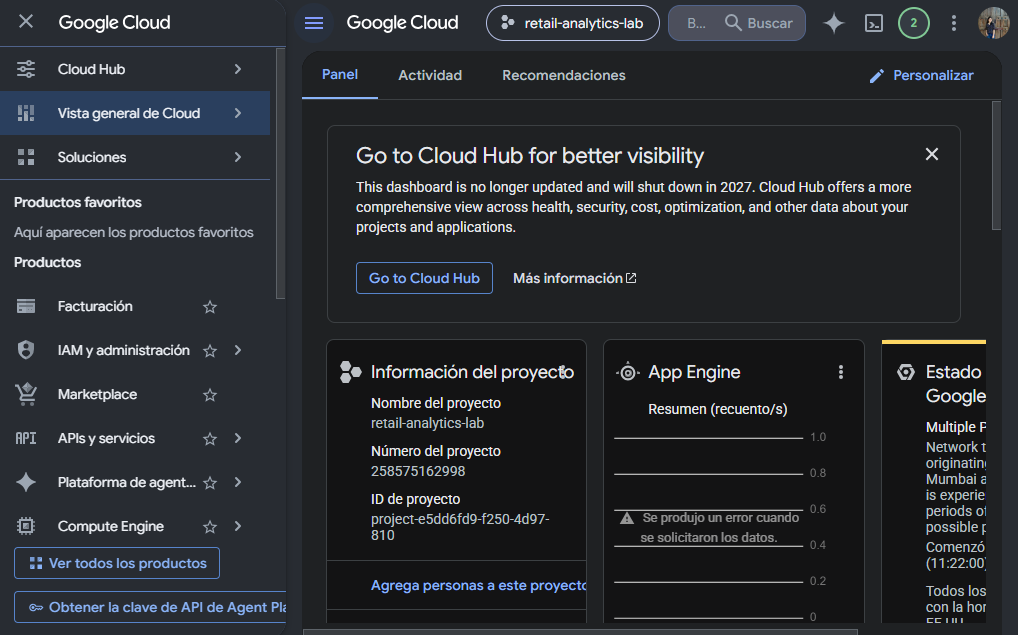

---

## Habilitar BigQuery API

Para permitir que Python interactúe programáticamente con el motor analítico desde nuestro entorno local, se activó la API de BigQuery en la consola de administración siguiendo esta ruta:

```text
Google Cloud Console
↓
APIs & Services
↓
Enable APIs and Services
↓
Buscar: BigQuery API ➔ Seleccionar ➔ Habilitar
```

**Evidencia de API Habilitada:**

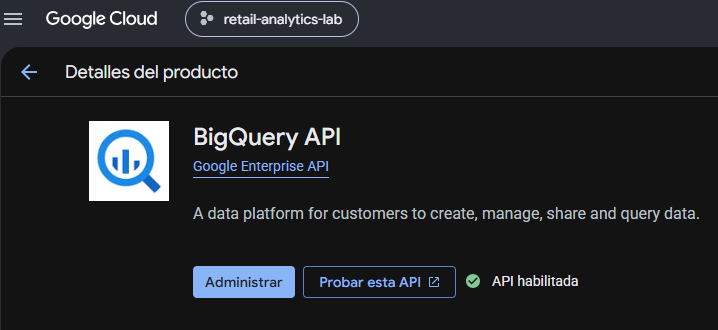

---

## Crear Service Account

Se creó una identidad de máquina dedicada a la automatización de procesos para permitir que los scripts locales ejecuten comandos en la nube de forma segura.

```text
IAM & Admin
↓
Service Accounts
↓
Create Service Account

```

* **Rol asignado:** `BigQuery Admin` (permiso total para la gestión y consulta del Data Warehouse).

**Evidencia de Cuenta de Servicio Autorizada:**

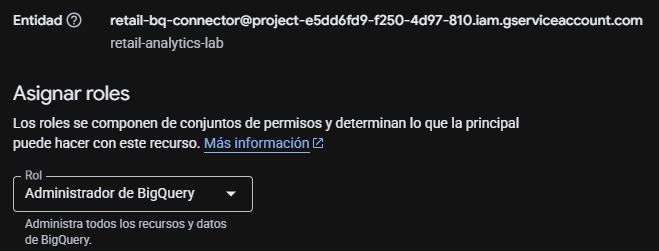

---

## Descargar Credenciales

Se generó y descargó la llave privada en formato JSON para permitir la autenticación remota.

```text
service_account.json

```

* **Ruta de almacenamiento local:** `/proyecto/credentials/`

> **Nota de Seguridad:** Se agregó la regla `credentials/` en el archivo `.gitignore` para evitar que la llave privada se suba al repositorio público de GitHub y proteger el acceso a la nube.

**Evidencia de Clave Privada Generada:**

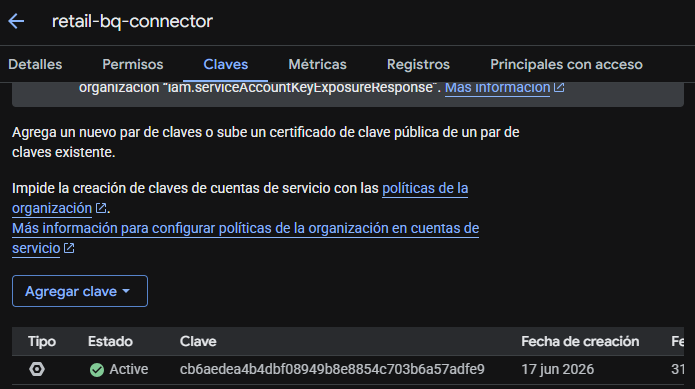

---

# Parte 4 y 5 - Creación de Dataset y Tablas (Modelo Star Schema) desde Python

Para inicializar la infraestructura de datos de forma automatizada, se utilizó la librería oficial `google-cloud-bigquery` en Jupyter. Esto permitió estructurar el almacén de datos directamente en la nube mediante un **Modelo en Estrella (Star Schema)** compuesto por tablas de dimensiones y una tabla de hechos central.

---

## 1. Inicialización del Dataset

Se creó programáticamente el espacio lógico (esquema) en la ubicación geográfica correspondiente:

```python
from google.cloud import bigquery

# Inicializar cliente con credenciales de gobernanza
client = bigquery.Client.from_service_account_json("credentials/service_account.json")

# Configurar y desplegar el Dataset
dataset_id = f"{client.project}.retail_dw"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

dataset = client.create_dataset(dataset, exists_ok=True)
print(f"Dataset {dataset.dataset_id} inicializado.")

```

---

## 2. Definición del Esquema Analítico (DDL)

Se encapsularon y ejecutaron las sentencias SQL correspondientes para construir el catálogo de dimensiones (`dim_clientes`, `dim_productos`) y la tabla transaccional de hechos (`fact_ventas`), aplicando restricciones analíticas de clave primaria.

```python
# Definición de consultas DDL
query_clientes = """
CREATE OR REPLACE TABLE retail_dw.dim_clientes (
    cliente_id STRING NOT NULL, nombre STRING, email STRING, telefono STRING, direccion STRING, fecha_registro DATE,
    PRIMARY KEY (cliente_id) NOT ENFORCED
);
"""

query_productos = """
CREATE OR REPLACE TABLE retail_dw.dim_productos (
    producto_id STRING NOT NULL, nombre_producto STRING, categoria STRING, precio_unitario FLOAT64,
    PRIMARY KEY (producto_id) NOT ENFORCED
);
"""

query_ventas = """
CREATE OR REPLACE TABLE retail_dw.fact_ventas (
    venta_id STRING NOT NULL, fecha_venta TIMESTAMP, cliente_id STRING, producto_id STRING, cantidad INT64, total_venta FLOAT64,
    PRIMARY KEY (venta_id) NOT ENFORCED
);
"""

# Ejecución de queries en el motor analítico
client.query(query_clientes).result()
client.query(query_productos).result()
client.query(query_ventas).result()
print("Estructura del Star Schema desplegada exitosamente.")

```

**Evidencia de Infraestructura y Esquema Desplegado en BigQuery:**

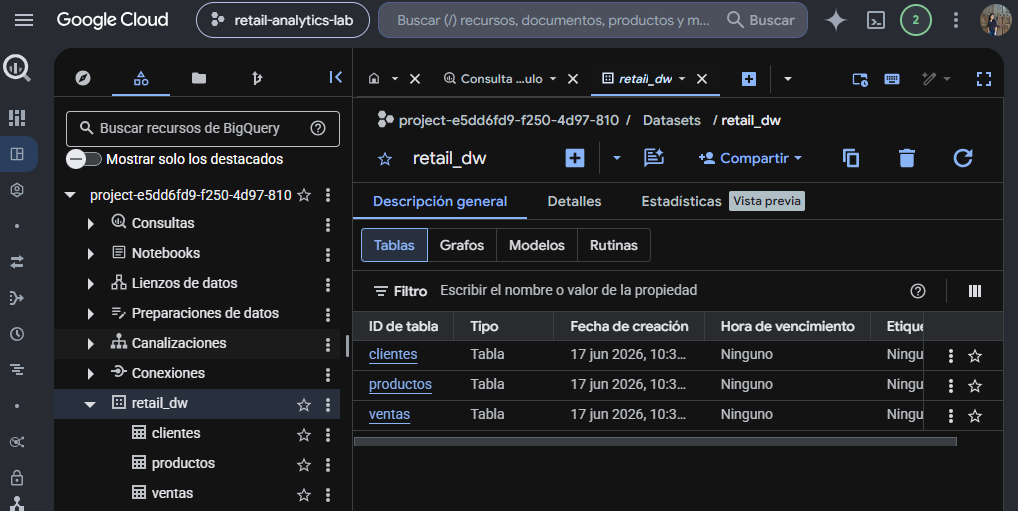

---